# Лабораторная работа № 8  
## Фильтр Калмана

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем генератор случайных чисел, чтобы результаты повторялись при каждом запуске
np.random.seed(42)


def calculate_rmse(true, estimated):
    """
    Расчёт среднеквадратичной ошибки RMSE.

    RMSE показывает среднее отклонение оценки фильтра от истинного значения.
    Чем меньше RMSE, тем точнее работает фильтр.
    """
    true = np.array(true)
    estimated = np.array(estimated)
    return np.sqrt(np.mean((true - estimated) ** 2))


def normalize_angle(angle):
    """
    Нормализация угла в диапазон [-pi, pi].
    Нужна для EKF, чтобы избежать скачков угла при переходе через +/- pi.
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi


def plot_time_series(time, true, measured, filtered, ylabel, title, cov_history=None):
    """
    График временного ряда:
    - истинное значение;
    - зашумлённые измерения;
    - оценка фильтра;
    - при необходимости история ковариации ошибки P.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(time, true, "k-", label="Истинное значение", linewidth=2)
    ax.plot(time, measured, "b.", label="Измерение (с шумом)", alpha=0.5)
    ax.plot(time, filtered, "r-", label="Оценка фильтра", linewidth=2)

    if cov_history is not None:
        plot_time = time[:len(cov_history)]
        ax2 = ax.twinx()
        ax2.plot(plot_time, cov_history, "g--", label="Ковариация ошибки P", alpha=0.6)
        ax2.set_ylabel("Ковариация ошибки P", color="green")
        ax2.tick_params(axis="y", labelcolor="green")
        ax2.set_ylim(0, max(cov_history) * 1.2)

    ax.set_xlabel("Время (шаг)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_trajectory_2d(true_x, true_y, meas_x, meas_y, est_x, est_y, title):
    """
    Построение 2D-траектории в плоскости X-Y.
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(true_x, true_y, "k-", label="Истинная траектория", lw=2)
    ax.plot(meas_x, meas_y, "b.", label="Измерения", alpha=0.4)
    ax.plot(est_x, est_y, "r-", label="Оценка фильтра", lw=2)

    ax.set_xlabel("X (м)")
    ax.set_ylabel("Y (м)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

# Задание 1. Скалярный фильтр Калмана

Нужно реализовать одномерный фильтр Калмана для оценки постоянной величины по зашумлённым измерениям.

RMSE (Задание 1): 0.508


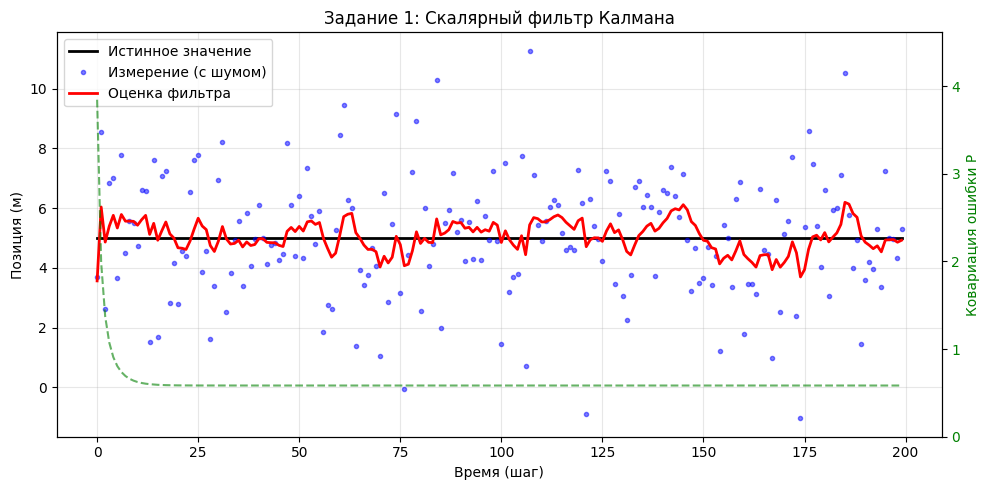

In [ ]:
# ======================== ЗАДАНИЕ 1 ========================

# --- 1. Симуляция данных ---
dt_1 = 0.05
N_1 = 200

true_pos_1 = 5.0 * np.ones(N_1)

noise_sigma_1 = 2.0 # шум датчика
measurements_1 = true_pos_1 + np.random.normal(0, noise_sigma_1, N_1)

time_1 = np.arange(N_1)


class KF1D:
    """
    Одномерный фильтр Калмана для статического объекта.

    Состояние:
        x = позиция

    Измерение:
        z = позиция + шум
    """
    def __init__(self, q, r):
        self.Q = q          # дисперсия шума процесса (датчика)
        self.R = r          # дисперсия шума измерения (модель)

        self.x = 0.0        # начальная оценка положения
        self.P = 100.0      # начальная ковариация ошибки

        self.F = 1.0        # модель перехода: x_k = x_{k-1}
        self.H = 1.0        # модель измерения: z_k = x_k

        self.P_history = [] # история ковариации ошибки

    def predict(self):
        """
        Этап предсказания.
        Для статического объекта состояние не меняется,
        но неопределённость увеличивается на Q.
        """
        self.x = self.F * self.x
        self.P = self.F * self.P * self.F + self.Q

    def update(self, z):
        """
        Этап коррекции по измерению z.
    """
        y = z - self.H * self.x                 # невязка
        S = self.H * self.P * self.H + self.R   # ковариация невязки
        K = self.P * self.H / S                 # коэффициент Калмана, =1 -> верим датчику

        self.x = self.x + K * y                 # обновление оценки
        self.P = (1 - K * self.H) * self.P      # обновление ковариации

        self.P_history.append(self.P)


# Параметры фильтра
Q_student_1 = 0.1
R_student_1 = noise_sigma_1 ** 2

kf_1 = KF1D(q=Q_student_1, r=R_student_1)

filtered_1 = []

for z in measurements_1:
    kf_1.predict()
    kf_1.update(z)
    filtered_1.append(kf_1.x)

rmse_1 = calculate_rmse(true_pos_1, filtered_1)

print(f"RMSE (Задание 1): {rmse_1:.3f}")

plot_time_series(
    time_1,
    true_pos_1,
    measurements_1,
    filtered_1,
    ylabel="Позиция (м)",
    title="Задание 1: Скалярный фильтр Калмана",
    cov_history=kf_1.P_history,
)

# Задание 2. Фильтр постоянной скорости

Нужно реализовать фильтр Калмана для объекта, который движется по прямой.


RMSE позиции (Задание 2): 0.533


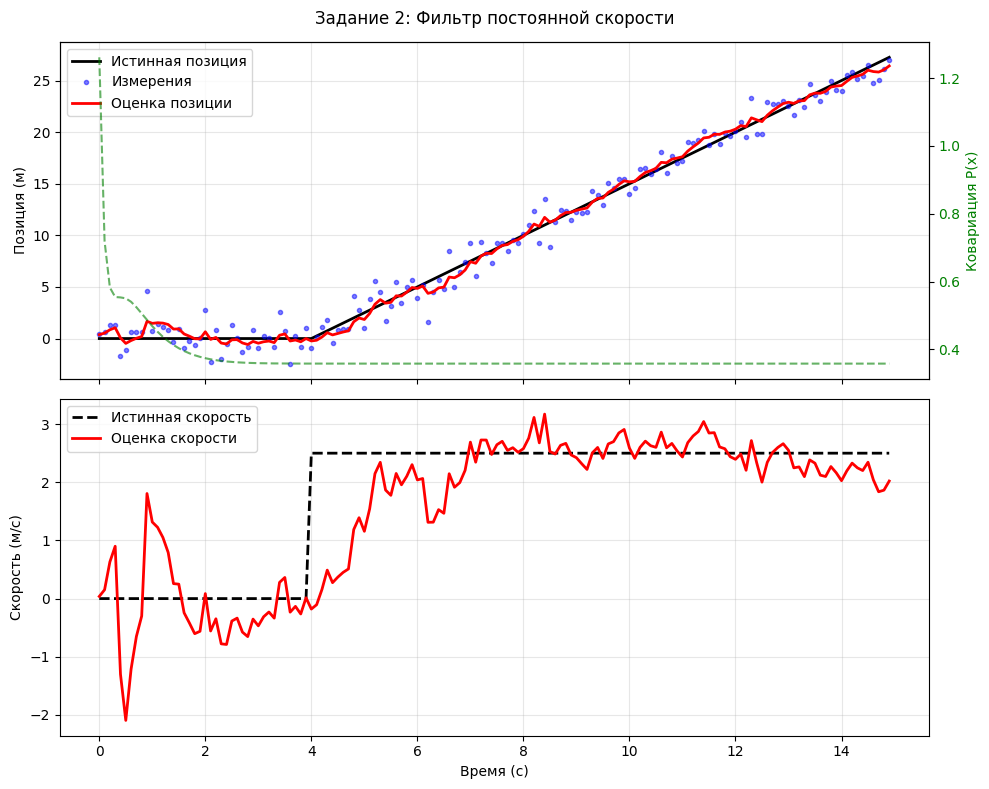

In [3]:
# ======================== ЗАДАНИЕ 2 ========================

# --- 1. Симуляция данных ---
dt_2 = 0.1
N_2 = 150

time_2 = np.arange(N_2) * dt_2

true_pos_2 = np.zeros(N_2)
true_vel_2 = np.zeros(N_2)

# С 40-го шага скорость скачком становится равной 2.5 м/с
true_vel_2[40:] = 2.5

# Интегрируем скорость, чтобы получить истинную позицию
for i in range(1, N_2):
    true_pos_2[i] = true_pos_2[i - 1] + true_vel_2[i - 1] * dt_2

noise_sigma_2 = 1.2
measurements_2 = true_pos_2 + np.random.normal(0, noise_sigma_2, N_2)


class KF_CV1D:
    """
    Фильтр Калмана для одномерного движения с постоянной скоростью.

    Состояние:
        x = [позиция, скорость]^T

    Измерение:
        z = позиция + шум
    """
    def __init__(self, dt, q_pos, q_vel, r_pos):
        self.dt = dt

        self.F = np.array([
            [1, dt],
            [0, 1]
        ], dtype=float)

        self.H = np.array([
            [1, 0]
        ], dtype=float)

        self.Q = np.diag([q_pos, q_vel]).astype(float)
        self.R = np.array([[r_pos]], dtype=float)

        self.x = np.array([
            [0.0],
            [0.0]
        ], dtype=float)

        self.P = np.eye(2) * 10.0

        self.P_pos_history = []

    def predict(self):
        """
        Матричное предсказание состояния и ковариации.
        """
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        """
        Коррекция по измерению позиции.
        """
        z = np.asarray(z, dtype=float)

        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y

        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P

        self.P_pos_history.append(self.P[0, 0])


# Параметры фильтра
q_pos_2 = 0.05
q_vel_2 = 0.08
r_pos_2 = noise_sigma_2 ** 2

kf_2 = KF_CV1D(dt=dt_2, q_pos=q_pos_2, q_vel=q_vel_2, r_pos=r_pos_2)

filtered_pos_2 = []
filtered_vel_2 = []

for z in measurements_2:
    kf_2.predict()
    kf_2.update(np.array([[z]]))

    filtered_pos_2.append(kf_2.x[0, 0])
    filtered_vel_2.append(kf_2.x[1, 0])

rmse_2 = calculate_rmse(true_pos_2, filtered_pos_2)

print(f"RMSE позиции (Задание 2): {rmse_2:.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_2, true_pos_2, "k-", label="Истинная позиция", lw=2)
ax1.plot(time_2, measurements_2, "b.", label="Измерения", alpha=0.5)
ax1.plot(time_2, filtered_pos_2, "r-", label="Оценка позиции", lw=2)

ax1_twin = ax1.twinx()
ax1_twin.plot(time_2, kf_2.P_pos_history, "g--", label="Ковариация P(x)", alpha=0.6)
ax1_twin.set_ylabel("Ковариация P(x)", color="green")
ax1_twin.tick_params(axis="y", labelcolor="green")

ax1.set_ylabel("Позиция (м)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.plot(time_2, true_vel_2, "k--", label="Истинная скорость", lw=2)
ax2.plot(time_2, filtered_vel_2, "r-", label="Оценка скорости", lw=2)
ax2.set_xlabel("Время (с)")
ax2.set_ylabel("Скорость (м/с)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Задание 2: Фильтр постоянной скорости")
plt.tight_layout()
plt.show()

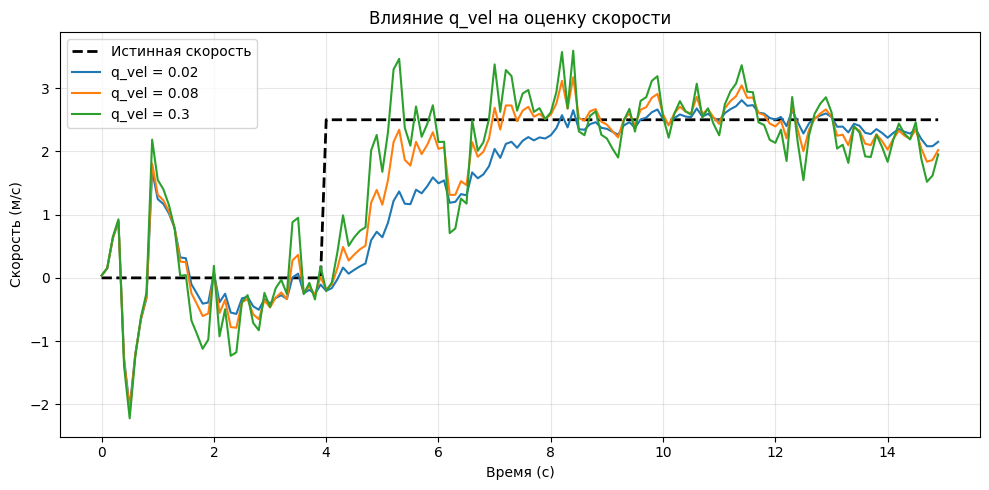

In [4]:
q_vel_values = [0.02, 0.08, 0.30]

plt.figure(figsize=(10, 5))

plt.plot(time_2, true_vel_2, "k--", label="Истинная скорость", lw=2)

for q_vel in q_vel_values:
    kf_tmp = KF_CV1D(
        dt=dt_2,
        q_pos=q_pos_2,
        q_vel=q_vel,
        r_pos=r_pos_2,
    )

    vel_tmp = []

    for z in measurements_2:
        kf_tmp.predict()
        kf_tmp.update(np.array([[z]]))
        vel_tmp.append(kf_tmp.x[1, 0])

    plt.plot(time_2, vel_tmp, label=f"q_vel = {q_vel}")

plt.xlabel("Время (с)")
plt.ylabel("Скорость (м/с)")
plt.title("Влияние q_vel на оценку скорости")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Задание 3. Двумерный трекинг

Нужно реализовать 2D-фильтр Калмана для отслеживания объекта, который движется по круговой траектории.


RMSE X: 0.749
RMSE Y: 0.736
RMSE total: 0.743


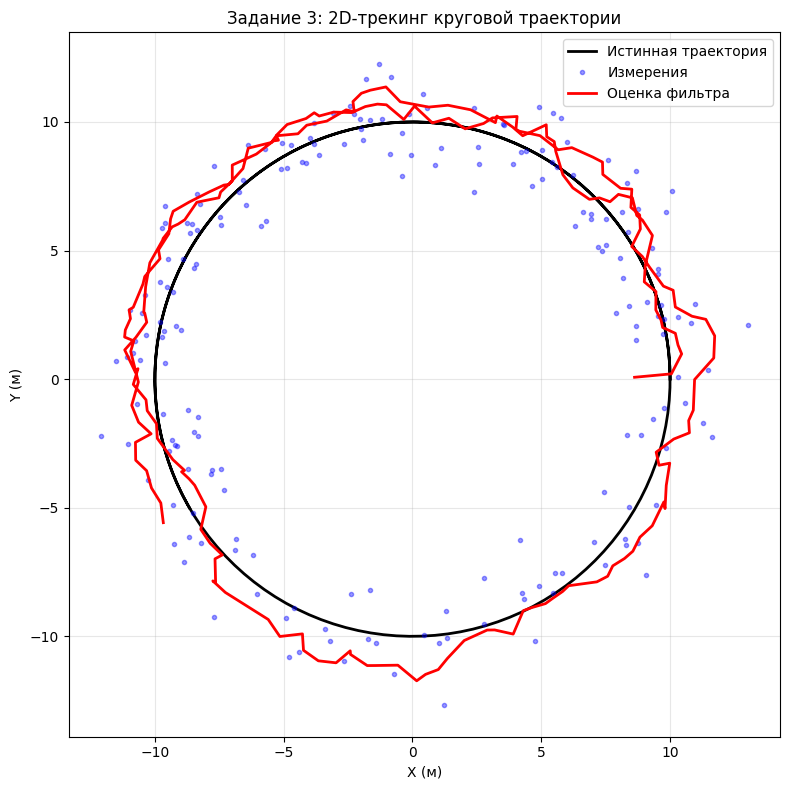

In [5]:
# ======================== ЗАДАНИЕ 3 ========================

# --- 1. Симуляция данных ---
dt_3 = 0.1
N_3 = 200

t_3 = np.arange(N_3)

omega_3 = 0.05

true_x_3 = 10 * np.cos(omega_3 * t_3)
true_y_3 = 10 * np.sin(omega_3 * t_3)

noise_sigma_3 = 1.0

meas_x_3 = true_x_3 + np.random.normal(0, noise_sigma_3, N_3)
meas_y_3 = true_y_3 + np.random.normal(0, noise_sigma_3, N_3)


class KF_2D_CV:
    """
    2D-фильтр Калмана с моделью постоянной скорости.

    Состояние:
        x = [x, vx, y, vy]^T

    Измерение:
        z = [x, y]^T
    """
    def __init__(self, dt, q, r):
        self.dt = dt

        F_block = np.array([
            [1, dt],
            [0, 1]
        ], dtype=float)

        self.F = np.block([
            [F_block, np.zeros((2, 2))],
            [np.zeros((2, 2)), F_block]
        ])

        self.H = np.array([
            [1, 0, 0, 0],
            [0, 0, 1, 0]
        ], dtype=float)

        self.Q = np.eye(4) * q
        self.R = np.eye(2) * r

        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 5.0

    def predict(self):
        """
        Предсказание состояния и ковариации.
        """
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        """
        Многомерная коррекция по измерениям x и y.
        """
        z = np.asarray(z, dtype=float)

        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y

        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P


# Параметры фильтра
q_3 = 0.05
r_3 = noise_sigma_3 ** 2

kf_3 = KF_2D_CV(dt=dt_3, q=q_3, r=r_3)

est_x_3 = []
est_y_3 = []

for mx, my in zip(meas_x_3, meas_y_3):
    z_vec = np.array([[mx], [my]])

    kf_3.predict()
    kf_3.update(z_vec)

    est_x_3.append(kf_3.x[0, 0])
    est_y_3.append(kf_3.x[2, 0])

rmse_x3 = calculate_rmse(true_x_3, est_x_3)
rmse_y3 = calculate_rmse(true_y_3, est_y_3)
rmse_total3 = np.sqrt((rmse_x3 ** 2 + rmse_y3 ** 2) / 2)

print(f"RMSE X: {rmse_x3:.3f}")
print(f"RMSE Y: {rmse_y3:.3f}")
print(f"RMSE total: {rmse_total3:.3f}")

plot_trajectory_2d(
    true_x_3,
    true_y_3,
    meas_x_3,
    meas_y_3,
    est_x_3,
    est_y_3,
    title="Задание 3: 2D-трекинг круговой траектории",
)